In [1]:
import pandas as pd

In [8]:
df = pd.read_parquet("kemsley_recipes.parquet")

In [12]:
[v for v in df.columns if "grade" in v.lower()]

['PM6 Grade ID']

In [15]:
df = pd.read_parquet("kemsley_recipes.parquet", columns=["Total Blend Cost","Combined Cost Adjusted [£/T]", "E Line Pulper MWP Furnish Operator Input", "E Line Pulper OKLS Furnish Operator Input",'PM6 Grade ID'])
df = df.rename(columns={"Total Blend Cost":"blend_cost", "Combined Cost Adjusted [£/T]":"process_cost",  "E Line Pulper MWP Furnish Operator Input":"mwp", "E Line Pulper OKLS Furnish Operator Input":"okls","PM6 Grade ID":"grade"})
df["grade"] = df["grade"].astype(int)

In [20]:
df["grade"].unique()

array([6010085, 3600085, 3600110, 3600100, 3600097, 3600112, 4805100,
       3600115, 4805097, 3600092, 4755082, 4805085, 3550082, 6010120,
       3500080, 6000120])

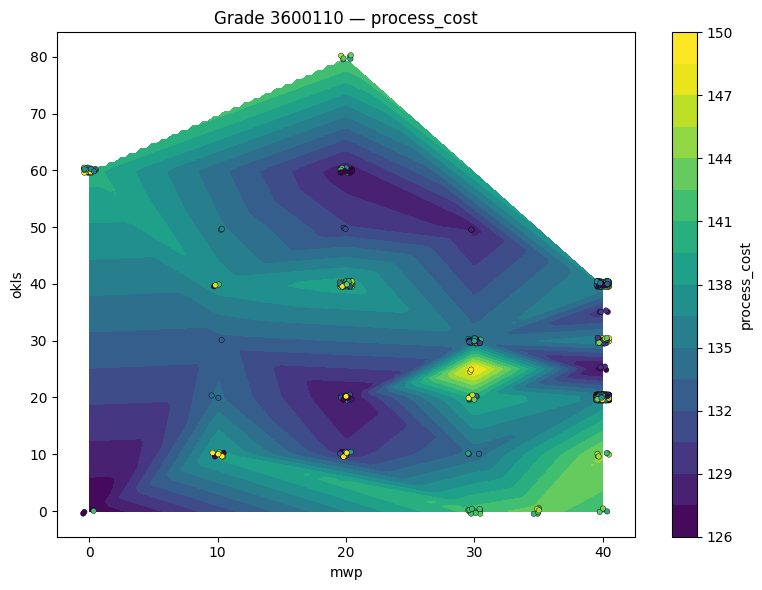

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

grade = 3600110
ycol = "process_cost"
clip_pct = 0.01  # percentile to clip (higher = more contrast, lower = less)

sub = df[df["grade"] == grade]
sub_agg = sub.groupby(["mwp", "okls"])[ycol].mean().reset_index()

xi = np.linspace(sub_agg["mwp"].min(), sub_agg["mwp"].max(), 100)
yi = np.linspace(sub_agg["okls"].min(), sub_agg["okls"].max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata(
    (sub_agg["mwp"].values, sub_agg["okls"].values),
    sub_agg[ycol].values,
    (Xi, Yi),
    method="linear",
)

vmin = np.nanpercentile(Zi, clip_pct)
vmax = np.nanpercentile(Zi, 100 - clip_pct)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(Xi, Yi, Zi, levels=20, cmap="viridis", vmin=vmin, vmax=vmax)

jitter_x = np.random.default_rng(42).uniform(-0.5, 0.5, len(sub))
jitter_y = np.random.default_rng(43).uniform(-0.5, 0.5, len(sub))
ax.scatter(sub["mwp"] + jitter_x, sub["okls"] + jitter_y, c=sub[ycol],
           cmap="viridis", vmin=vmin, vmax=vmax, s=15, edgecolors="k", linewidths=0.3)

plt.colorbar(cs, ax=ax, label=ycol)
ax.set_xlabel("mwp")
ax.set_ylabel("okls")
ax.set_title(f"Grade {grade} — {ycol}")
plt.tight_layout()
plt.show()

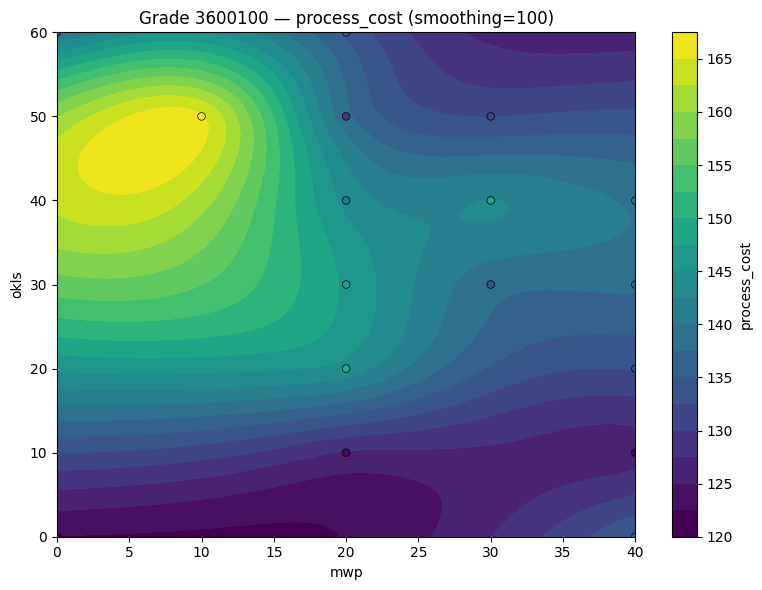

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator

grade = 3600100
ycol = "process_cost"
clip_pct = 0.1 # percentile to clip (higher = more contrast, lower = less)
smoothing = 100 # 0 = exact interpolation, larger = smoother
plot_all_dots = False  # True = all observations with jitter, False = aggregated means

sub = df[df["grade"] == grade]
sub_agg = sub.groupby(["mwp", "okls"])[ycol].mean().reset_index()

x = sub_agg["mwp"].values.astype(float)
y = sub_agg["okls"].values.astype(float)
z = sub_agg[ycol].values.astype(float)

points = np.column_stack([x, y])
rbf = RBFInterpolator(points, z, smoothing=smoothing, kernel="thin_plate_spline")

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)
grid_points = np.column_stack([Xi.ravel(), Yi.ravel()])
Zi = rbf(grid_points).reshape(Xi.shape)

vmin = np.nanpercentile(Zi, clip_pct)
vmax = np.nanpercentile(Zi, 100 - clip_pct)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(Xi, Yi, Zi, levels=20, cmap="viridis", vmin=vmin, vmax=vmax)

if plot_all_dots:
    jitter_x = np.random.default_rng(42).uniform(-0.5, 0.5, len(sub))
    jitter_y = np.random.default_rng(43).uniform(-0.5, 0.5, len(sub))
    ax.scatter(sub["mwp"] + jitter_x, sub["okls"] + jitter_y, c=sub[ycol],
               cmap="viridis", vmin=vmin, vmax=vmax, s=15, edgecolors="k", linewidths=0.3)
else:
    ax.scatter(sub_agg["mwp"], sub_agg["okls"], c=sub_agg[ycol],
               cmap="viridis", vmin=vmin, vmax=vmax, s=30, edgecolors="k", linewidths=0.5)

plt.colorbar(cs, ax=ax, label=ycol)
ax.set_xlabel("mwp")
ax.set_ylabel("okls")
ax.set_title(f"Grade {grade} — {ycol} (smoothing={smoothing})")
plt.tight_layout()
plt.show()

